# Day 3: 材料数据库与材料机器学习数据探索

今天的目标：

- 认识常见材料数据库：Materials Project、OQMD、AFLOW、JARVIS、Matbench。
- 理解材料机器学习数据表通常包含哪些字段。
- 明确第一周项目的预测目标：带隙 `band_gap_eV`。
- 学会做材料数据探索：样本数、缺失值、带隙分布、金属比例、材料类别分组。

今天先使用一个本地小型示例数据集，模拟真实材料数据库中的常见字段。这样可以先掌握分析流程，不被 API key、网络下载和环境安装卡住。


In [3]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "../.matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
DOCS_DIR = PROJECT_ROOT / "docs"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: /mnt/d/桌面/ai—study/day03


## 1. 常见材料数据库

下面是你后续做 AI for Materials 项目会经常遇到的数据来源：

| 数据库 | 主要内容 | 对你当前项目的意义 |
| --- | --- | --- |
| Materials Project | DFT 计算材料结构和性质，如形成能、带隙、能量、稳定性 | 后续可用 API 获取材料性质数据 |
| OQMD | 大量 DFT 计算的无机材料热力学数据 | 适合做形成能、稳定性相关任务 |
| AFLOW | 高通量 DFT 数据库 | 可用于材料筛选和性质预测 |
| JARVIS | NIST 维护的材料数据库，包含 DFT、机器学习和多种性质 | 可用于带隙、弹性、二维材料等任务 |
| Matbench | 材料机器学习 benchmark 集合 | 最适合入门，很多任务已经整理好 |

第一周建议优先理解 Matbench 风格的数据：一个任务通常就是一个表格，包含材料表示和目标性质。


## 2. 构造一个小型材料数据库示例

这个小数据集包含真实项目常见字段：

- `material_id`：材料编号。
- `formula`：化学式。
- `band_gap_eV`：带隙，今天的预测目标。
- `formation_energy_eV_atom`：形成能。
- `e_above_hull_eV_atom`：凸包以上能量，粗略表示稳定性。
- `crystal_system`：晶系。
- `material_family`：材料类别。

注意：这里的数据用于学习流程，不用于科研结论。


In [17]:
materials_db = pd.DataFrame({
    "material_id": [
        "mp-demo-001", "mp-demo-002", "mp-demo-003", "mp-demo-004", "mp-demo-005",
        "mp-demo-006", "mp-demo-007", "mp-demo-008", "mp-demo-009", "mp-demo-010",
        "mp-demo-011", "mp-demo-012", "mp-demo-013", "mp-demo-014", "mp-demo-015",
        "mp-demo-016", "mp-demo-017", "mp-demo-018", "mp-demo-019", "mp-demo-020",
    ],
    "formula": [
        "Si", "Ge", "GaAs", "TiO2", "ZnO", "Al2O3", "Fe", "Cu", "MoS2", "SnO2",
        "WO3", "In2O3", "NiO", "CuO", "CeO2", "BaTiO3", "SrTiO3", "CdS", "PbS", "Graphene",
    ],
    "band_gap_eV": [
        1.12, 0.67, 1.42, 3.20, 3.37, 8.80, 0.00, 0.00, 1.80, 3.60,
        2.70, 2.90, 3.60, 1.40, 3.20, 3.20, 3.25, 2.42, 0.40, 0.00,
    ],
    "formation_energy_eV_atom": [
        0.00, 0.00, -0.35, -3.05, -1.75, -3.40, 0.00, 0.00, -1.10, -2.10,
        -2.50, -2.20, -1.25, -0.90, -3.00, -2.85, -2.90, -0.95, -0.45, 0.00,
    ],
    "e_above_hull_eV_atom": [
        0.00, 0.01, 0.02, 0.00, 0.01, 0.00, 0.00, 0.00, 0.03, 0.00,
        0.02, 0.01, 0.04, 0.05, 0.00, 0.02, 0.01, 0.03, 0.08, 0.00,
    ],
    "crystal_system": [
        "cubic", "cubic", "cubic", "tetragonal", "hexagonal", "trigonal", "cubic", "cubic", "hexagonal", "tetragonal",
        "monoclinic", "cubic", "cubic", "monoclinic", "cubic", "tetragonal", "cubic", "hexagonal", "cubic", "hexagonal",
    ],
    "material_family": [
        "element", "element", "III-V", "oxide", "oxide", "oxide", "element", "element", "chalcogenide", "oxide",
        "oxide", "oxide", "oxide", "oxide", "oxide", "oxide", "oxide", "chalcogenide", "chalcogenide", "element",
    ],
})

raw_path = RAW_DATA_DIR / "day3_demo_materials_database.csv"
materials_db.to_csv(raw_path, index=False)
materials_db.head()


,material_id,formula,band_gap_eV,formation_energy_eV_atom,e_above_hull_eV_atom,crystal_system,material_family
0,mp-demo-001,Si,1.12,0.00,0.00,cubic,element
1,mp-demo-002,Ge,0.67,0.00,0.01,cubic,element
2,mp-demo-003,GaAs,1.42,-0.35,0.02,cubic,III-V
3,mp-demo-004,TiO2,3.20,-3.05,0.00,tetragonal,oxide
4,mp-demo-005,ZnO,3.37,-1.75,0.01,hexagonal,oxide


## 3. 读取数据并查看字段

真实项目第一步永远是先看数据，不要直接训练模型。


In [5]:
df = pd.read_csv(RAW_DATA_DIR / "day3_demo_materials_database.csv")
print("Shape:", df.shape)
df.head()


Shape: (20, 7)


,material_id,formula,band_gap_eV,formation_energy_eV_atom,e_above_hull_eV_atom,crystal_system,material_family
0,mp-demo-001,Si,1.12,0.00,0.00,cubic,element
1,mp-demo-002,Ge,0.67,0.00,0.01,cubic,element
2,mp-demo-003,GaAs,1.42,-0.35,0.02,cubic,III-V
3,mp-demo-004,TiO2,3.20,-3.05,0.00,tetragonal,oxide
4,mp-demo-005,ZnO,3.37,-1.75,0.01,hexagonal,oxide


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   material_id               20 non-null     object 
 1   formula                   20 non-null     object 
 2   band_gap_eV               20 non-null     float64
 3   formation_energy_eV_atom  20 non-null     float64
 4   e_above_hull_eV_atom      20 non-null     float64
 5   crystal_system            20 non-null     object 
 6   material_family           20 non-null     object 
dtypes: float64(3), object(4)
memory usage: 1.2+ KB


In [7]:
df.describe()


,band_gap_eV,formation_energy_eV_atom,e_above_hull_eV_atom
count,20.000000,20.000000,20.000000
mean,2.352500,-1.437500,0.016500
std,1.999347,1.223442,0.021095
min,0.000000,-3.400000,0.000000
25%,1.007500,-2.587500,0.000000
50%,2.560000,-1.175000,0.010000
75%,3.212500,-0.262500,0.022500
max,8.800000,0.000000,0.080000


你应该观察：

- 有多少个材料？
- 哪些列是数值列？
- `band_gap_eV` 的范围是多少？
- 是否有 `band_gap_eV = 0` 的金属或半金属？


## 4. 缺失值检查

材料数据库常见问题包括：缺失带隙、缺失结构、重复材料、单位不一致、字段名称不一致。


In [8]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary


material_id                 0
formula                     0
band_gap_eV                 0
formation_energy_eV_atom    0
e_above_hull_eV_atom        0
crystal_system              0
material_family             0
dtype: int64

## 5. 带隙分布

带隙预测项目中，先看目标分布非常重要。否则你不知道数据是否被金属样本、宽带隙绝缘体或某一类材料主导。


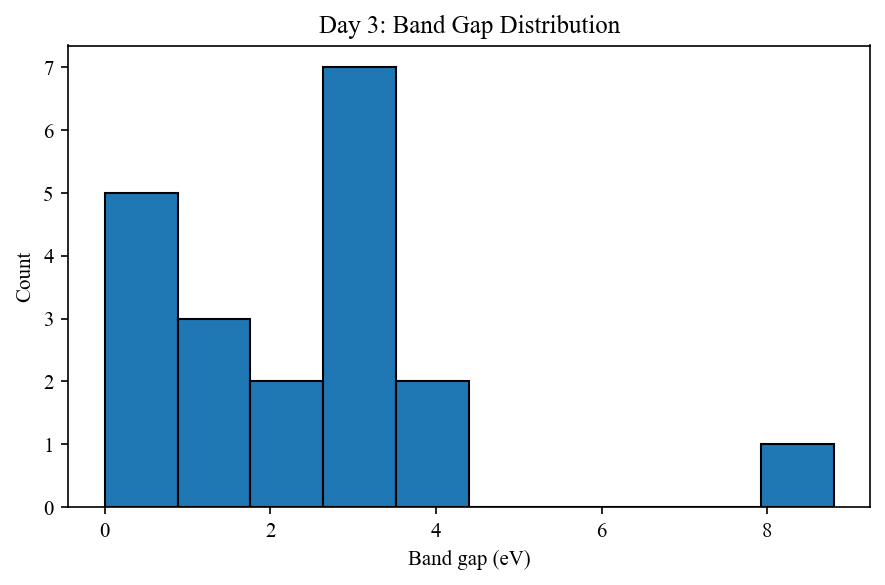

In [9]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.hist(df["band_gap_eV"], bins=10, edgecolor="black")
ax.set_xlabel("Band gap (eV)")
ax.set_ylabel("Count")
ax.set_title("Day 3: Band Gap Distribution")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "day3_band_gap_distribution.png", dpi=300)
plt.show()


In [10]:
metal_count = (df["band_gap_eV"] == 0).sum()
nonmetal_count = (df["band_gap_eV"] > 0).sum()
wide_gap_count = (df["band_gap_eV"] > 3).sum()

print("band_gap = 0 的材料数量:", metal_count)
print("band_gap > 0 的材料数量:", nonmetal_count)
print("band_gap > 3 eV 的材料数量:", wide_gap_count)


band_gap = 0 的材料数量: 3
band_gap > 0 的材料数量: 17
band_gap > 3 eV 的材料数量: 8


## 6. 按材料类别分组统计

分组统计能帮你发现数据偏差。例如，如果数据集中大部分都是氧化物，那么模型可能更擅长预测氧化物，而不一定适合硫化物或元素单质。


In [11]:
family_summary = (
    df.groupby("material_family")  # 按 material_family 列的值进行分组，相同材料家族的行被分到同一组。
    .agg(  # 对每个分组进行聚合计算，同时计算多个统计量：
        n_materials=("material_id", "count"), # 统计每个家族的材料数量（计数）
        mean_gap=("band_gap_eV", "mean"),
        min_gap=("band_gap_eV", "min"),
        max_gap=("band_gap_eV", "max"),
        mean_e_hull=("e_above_hull_eV_atom", "mean"),
    )
    .sort_values("n_materials", ascending=False)  # 按 n_materials 列降序排列，即材料数量最多的家族排在最前面
)
family_summary


,n_materials,mean_gap,min_gap,max_gap,mean_e_hull
material_family,,,,,
oxide,11,3.565455,1.40,8.80,0.014545
element,5,0.358000,0.00,1.12,0.002000
chalcogenide,3,1.540000,0.40,2.42,0.046667
III-V,1,1.420000,1.42,1.42,0.020000


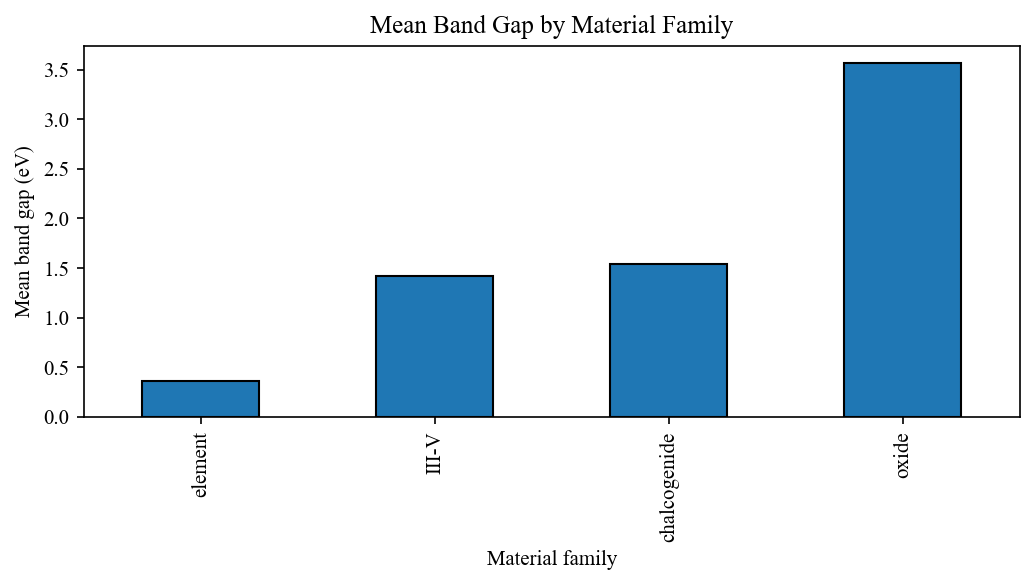

In [12]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
family_summary["mean_gap"].sort_values().plot(kind="bar", ax=ax, edgecolor="black") # 绘制按平均带隙排序的柱状图，x轴为材料家族，y轴为平均带隙
ax.set_xlabel("Material family")
ax.set_ylabel("Mean band gap (eV)")
ax.set_title("Mean Band Gap by Material Family")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "day3_mean_gap_by_family.png", dpi=300)
plt.show()


## 7. 稳定性筛选示例

材料项目中经常会筛选相对稳定的材料。例如可以粗略使用：

```text
e_above_hull_eV_atom <= 0.05
```

这不是绝对标准，但常用于入门理解。


In [13]:
stable_df = df[df["e_above_hull_eV_atom"] <= 0.05].copy()
print("稳定材料数量:", len(stable_df))
stable_df[["material_id", "formula", "band_gap_eV", "e_above_hull_eV_atom", "material_family"]]


稳定材料数量: 19


,material_id,formula,band_gap_eV,e_above_hull_eV_atom,material_family
0,mp-demo-001,Si,1.12,0.00,element
1,mp-demo-002,Ge,0.67,0.01,element
2,mp-demo-003,GaAs,1.42,0.02,III-V
3,mp-demo-004,TiO2,3.20,0.00,oxide
4,mp-demo-005,ZnO,3.37,0.01,oxide
5,mp-demo-006,Al2O3,8.80,0.00,oxide
6,mp-demo-007,Fe,0.00,0.00,element
7,mp-demo-008,Cu,0.00,0.00,element
8,mp-demo-009,MoS2,1.80,0.03,chalcogenide
9,mp-demo-010,SnO2,3.60,0.00,oxide


In [14]:
processed_path = PROCESSED_DATA_DIR / "day3_stable_materials.csv"
stable_df.to_csv(processed_path, index=False)
processed_path


PosixPath('/mnt/d/桌面/ai—study/day03/data/processed/day3_stable_materials.csv')

## 8. 写一页数据理解笔记

请把今天对材料数据库和带隙预测任务的理解写入 `docs/day3_materials_data_notes.md`。下面先生成一个模板，你需要自己补充其中的 TODO。


In [ ]:
notes_path = DOCS_DIR / "day3_materials_data_notes.md"
notes_template = """# Day 3 材料数据理解笔记

## 今天认识的数据来源

- Materials Project：是大型材料数据库，包含材料结构、能量、带隙、形成能、稳定性等DFT计算结果，适合获取真实材料数据
- OQMD：主要是无机材料的热力学性质
- AFLOW：暂未知
- JARVIS：暂未知
- Matbench：机器学习材料库，已经整理好了适合建模的任务，适合入门

## 为什么带隙预测适合作为入门任务

从物理意义上看，带隙是研究材料电子性质最基础的物理量之一，并且也是材料在多种应用中其决定因素的先决条件。
从数据类型来客，带隙是一个最易获得的物理量，只需要对弛豫后的结构进行能带计算就可得到，因此有大量的现成数据可提供。
从回归任务来看，带隙是一个从0开始的数值，并且范围不会过大，适合作为目标变量进行预测。

## 今天这个数据表的字段

- material_id：材料编号
- formula：化学式
- band_gap_eV：带隙，单位 eV，是本项目的预测目标
- formation_energy_eV_atom：形成能，单位 eV/atom
- e_above_hull_eV_atom：凸包以上能量，单位 eV/atom
- crystal_system：晶系
- material_family：材料类别

## 我观察到的数据特点

材料类型主要以氧化物居多共11种，带隙分布也更广。

## 如果后续预测吸附能，需要改哪里

如果是做吸附能预测，可能需要改动的地方包括：

- 标签 y：将带隙 band_gap_eV 替换为吸附能
- 特征量标签 x：可能需要增加结构特征、吸附位点特征等

"""
notes_path.write_text(notes_template, encoding="utf-8")
notes_path


PosixPath('/mnt/d/桌面/ai—study/day03/docs/day3_materials_data_notes.md')

## 9. 今日练习

请你完成下面几个练习：

1. 找出 `band_gap_eV > 3` 且 `e_above_hull_eV_atom <= 0.05` 的材料。
2. 统计每个 `crystal_system` 的平均带隙。
3. 画出 `formation_energy_eV_atom` vs `band_gap_eV` 的散点图。
4. 保存筛选后的宽带隙稳定材料到 `data/processed/day3_stable_wide_gap_materials.csv`。
5. 补完 `docs/day3_materials_data_notes.md` 中的 TODO。


In [22]:
# 练习 1：筛选宽带隙且相对稳定的材料
stable_wide_gap_df = df[(df["band_gap_eV"] > 3.0) & (df["e_above_hull_eV_atom"] <= 0.05)]
stable_wide_gap_df.shape

(8, 7)

In [23]:
# 练习 2：统计每个 crystal_system 的平均带隙
df.groupby("crystal_system")["band_gap_eV"].mean().sort_values(ascending=False)

crystal_system
trigonal      8.800000
tetragonal    3.333333
monoclinic    2.050000
hexagonal     1.897500
cubic         1.656000
Name: band_gap_eV, dtype: float64

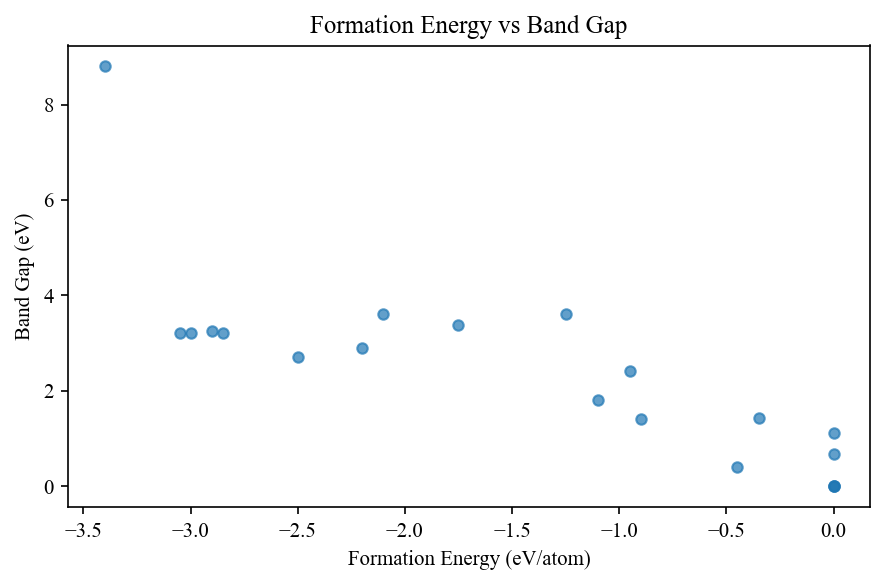

In [24]:
# 练习 3：画 formation_energy_eV_atom vs band_gap_eV 散点图，并保存到 results/figures/
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.plot(df["formation_energy_eV_atom"], df["band_gap_eV"], "o", markersize=5, alpha=0.7)
ax.set_xlabel("Formation Energy (eV/atom)")
ax.set_ylabel("Band Gap (eV)")
ax.set_title("Formation Energy vs Band Gap")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "day3_formation_energy_vs_band_gap.png", dpi=300)
plt.show()

In [25]:
# 练习 4：保存宽带隙稳定材料 CSV
stable_wide_gap_df.to_csv(PROCESSED_DATA_DIR / "day3_stable_wide_gap_materials.csv", index=False)

In [30]:
# 练习 5：补完 docs/day3_materials_data_notes.md 后，读取前几行确认
with open(DOCS_DIR / "day3_materials_data_notes.md", "r", encoding="utf-8") as f:
    content = f.read() # 读取文件为字符串
print(content[:200])  # 打印前200个字符

# Day 3 材料数据理解笔记

## 今天认识的数据来源

- Materials Project：包含大量材料的结构、能带、热力学性质等信息
- OQMD：主要是无机材料的热力学性质
- AFLOW：暂未知
- JARVIS：暂未知
- Matbench：机器学习材料库，适合入门

## 为什么带隙预测适合作为入门任务

TODO：从物理意义、数据形式、回归任务三个角度解释。
从物理意义上看


In [33]:
#按行读取
with open(DOCS_DIR / "day3_materials_data_notes.md", "r", encoding="utf-8") as f:
    for line in f:
        print(line.strip())  # 打印每一行，去掉首尾空白字符
        break  # 只打印第一行

# Day 3 材料数据理解笔记


## 10. 今日自查

完成 Day 3 后，请确认你能回答：

- Materials Project、Matbench 分别适合做什么？
- 为什么第一周建议先用整理好的 CSV 或 Matbench，而不是直接写 API？
- 带隙预测中的 `y` 是哪一列？
- 为什么要先画带隙分布？
- `band_gap_eV = 0` 的样本可能代表什么？
- 为什么要关注材料类别分布？
- 如果数据大部分是氧化物，模型可能有什么偏差？
